> 极致的工程优化。

- resources
    - https://kellerjordan.github.io/posts/muon/
    - https://github.com/KellerJordan/cifar10-airbench

In [1]:
import torch
import torch.nn.functional as F

- Muon is an optimizer for 2D parameters of neural network hidden layers.
- And for an empirically-flavored motivation, we observe that based on manual inspection, the updates produced by both SGD-momentum and Adam for the 2D parameters in transformer-based neural networks typically have very **high condition number**. That is, they are almost **low-rank matrices**, with the updates for all neurons being dominated by just a few directions. We speculate that orthogonalization effectively increases the scale of other “rare directions” which have small magnitude in the update but are nevertheless important for learning.
    - 神经网络中2D参数的更新通常具有非常高的条件数。也就是说，它们几乎是低秩矩阵，所有神经元的更新都被少数几个方向主导。
    - 正交化会“有效地增加其他‘稀有方向’的尺度”。这意味着，尽管次要任务的原始梯度信号很弱，但在正交化之后，这个方向在最终的 update 矩阵中会被放大，其重要性得到提升。
- When training a neural network with Muon, scalar and vector parameters of the network, as well as the input and output layers, should be optimized by a standard method such as AdamW. Muon can be used for 4D convolutional parameters by flattening their last three dimensions.
    - Muon 的核心是“白化”梯度，即抹去梯度的大小（奇异值），只保留其方向。
    - 对于输出层，我们希望模型能够学习到不同特征对于最终分类的重要性。例如，某个从卷积层提取的特征可能对识别“猫”至关重要，而对识别“汽车”无关紧要。这种重要性会体现在梯度的尺度上，从而让优化器（如SGD或Adam）大幅调整对应的权重。
    - 输入层：权重不被训练: 请注意代码中的 `self.whiten.weight.requires_grad = False`。它的权重是通过 init_whiten 函数，利用训练数据的统计特性（协方差矩阵）一次性计算出来的（这是一种ZCA白化），之后就被冻结，不参与反向传播和梯度更新。既然没有梯度，自然也谈不上用任何优化器去优化它。
    - 偏置项 (Bias) 是向量: 输入层唯一需要学习的参数是它的偏置项 self.whiten.bias，这是一个向量。Muon 是为2D矩阵设计的，不适用于向量。因此，这个偏置项也被交给了SGD优化器处理。
- Muon (MomentUm Orthogonalized by Newton-Schulz) optimizes **2D neural network parameters** by taking the updates generated by SGD-momentum, and then applying a Newton-Schulz (NS) iteration as a post-processing step to each of them before applying them to the parameters.

- orthogonal matrix: $Q^TQ=I$
    - 几何上刻画旋转（rotation）和反射（reflection）
        - det(Q) = 1，表示旋转
            - $Q= \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}$
                - (1, 0) => (0, 1)
        - det(Q) = -1，则表示反射
            - $Q = \begin{pmatrix} -1 & 0 \\ 0 & 1 \end{pmatrix}$
                - (x, y) => (-x, y)
            - $Q = \begin{pmatrix} 1 & 0 & 0 \\ 0 & -1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$
                - (x, y, z) => (x, -y, z)
- 矩阵的 0 次幂（zeroth power）
    - 奇异值分解（SVD）中的正交部分
- zeropower_via_newtonschulz5（3次五次多项式迭代，快速地计算出梯度矩阵的近似正交部分（UV^T），实现梯度的白化）
    - zeropower: 计算矩阵的零次幂。
    - via_newtonschulz: 通过“牛顿-舒尔茨（Newton-Schulz）”迭代算法来实现。这是一种避免直接进行昂贵的SVD分解的数值方法。
    - 5: 指的是迭代中使用了一个五次（quintic）多项式。
- sgd vs. netwon vs. Muon
    - sgd: $w - \eta \cdot g$
    - netwon: $w - \eta \cdot H^{-1} g$
    - Muon: $w - \eta \cdot \text{zeropower}(g)$

## Gradient Whitening

- 在标准的梯度下降中，我们沿着负梯度方向更新权重。但如果梯度的各个维度之间相关性很高，或者尺度差异很大，优化过程就会很慢。
- “白化”变换旨在解耦 (decorrelate) 梯度的各个维度，并将其尺度归一化 (normalize scale)，使得优化路径更直接、高效。

### SVD

任何一个矩阵 G 都可以进行奇异值分解（SVD）：
$$
G = U S V^T
$$
- U 和 V 是正交矩阵（Orthogonal Matrices）。它们的列向量是标准正交的。
- S 是一个对角矩阵，对角线上的值是奇异值（Singular Values），表示了 G 在各个主方向上的“拉伸”或“缩放”程度。
- SVD 几何上的意义
    - $V^T$：一次旋转/反射
    - $S$：沿着新的坐标轴进行缩放（拉伸或压缩）。奇异值就是缩放的比例。
    - $U$：另一次旋转/反射。

矩阵 G 的“零次幂” G^0 在这里的定义是
$$
G^0 = U S^0 V^T
$$ 

其中 $S^0$ 是将 S 的所有非零对角元（奇异值）都替换为1得到的对角矩阵。因此，最终结果是：

$$
G^0 = U I V^T = UV^T
$$

这个 $UV^T$ 矩阵是一个正交矩阵（$(UV^T)(VU^T)=I$），它保留了原始矩阵 G 的“旋转”或“方向”信息，但完全丢弃了其“缩放”或“大小”的信息（因为所有奇异值都变成了1）。在信号处理和机器学习中，这个过程被称为白化（Whitening），因为它使得变换后的数据在各个方向上的方差都相等（均为1）。数学上的意义：
- 正交矩阵代表一种保距变换（Isometry），比如旋转（Rotation）或反射（Reflection）。它在对向量进行变换时，不会改变向量的长度，也不会改变向量之间的夹角。它只改变方向。
- 它的所有列向量（和行向量）构成一组标准正交基（Orthonormal Basis）。也就是说，每个列向量的长度都是1，且任意两个不同的列向量都相互垂直（点积为0）。

### 牛顿-舒尔茨迭代

直接计算SVD（torch.linalg.svd）对于大矩阵来说计算成本很高。因此，作者采用了一种更快的迭代逼近方法：牛顿-舒尔茨迭代。



In [2]:
@torch.compile
def zeropower_via_newtonschulz5(G, steps=3, eps=1e-7):
    """
    Newton-Schulz iteration to compute the zeroth power / orthogonalization of G.
    """
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps) # ensure top singular value <= 1
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.float() # 返回 float 方便对比

```python
X /= (X.norm() + eps) # ensure top singular value <= 1
```

- 矩阵的 Frobenius Norm （F范数）总是大于或等于其谱范数（Spectral Norm，即最大奇异值）。
    - 对于矩阵 $X$ 奇异值假设为 $\sigma_1,\sigma_2, \cdots, \sigma_r$（降序排列 $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0$）
    - 谱范数：$||X||_2 = \sigma_{max} = \sigma_1$
        - $||X||_2^2 = \sigma_1^2$
    - F范数：$||X||_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |x_{ij}|^2} = \sqrt{\sum_{k=1}^r \sigma_k^2}$
        - $||X||_F^2 = \sigma_1^2 + \sigma_2^2 + \dots + \sigma_r^2$
    - $||X||_F^2 \ge ||X||_2^2$
- `torch.norm`: defaut fro
    -  `X_norm = X / X.norm()`
        -  $||X_{norm}||_2 = ||\frac{1}{||X||_F} \cdot X||_2 = \frac{1}{||X||_F} \cdot ||X||_2 \leq \frac{1}{||X||_F} \cdot ||X||_F=1$
-  其他范数
    -  核范数（nuclear norm）
        - $||X||_* = \sum_{k=1}^r \sigma_k = \sigma_1 + \sigma_2 + \dots + \sigma_r$
        - 矩阵的迹 (Trace) 是其对角线元素之和，也等于其所有特征值 (Eigenvalues) 之和。
        - 矩阵的核范数 (Nuclear Norm) 是其所有奇异值 (Singular Values) 之和。
        - 对于一个半正定矩阵 $X^T X$，它的奇异值和特征值是相同的。核范数的严格定义是 $||X||_* = \text{Tr}(\sqrt{X^T X})$，即矩阵 $(X^T X)^{1/2}$ 的迹；

In [3]:
torch.manual_seed(123)
rows, cols = 4, 6
X = torch.randn(rows, cols) * 10 
X_f = X.norm()
X_f

tensor(46.1010)

In [4]:
sigmas = torch.linalg.svdvals(X)
sigmas

tensor([33.6294, 25.1017, 16.3428,  9.8583])

In [24]:
top_sigma = sigmas[0]
top_sigma

tensor(33.6294)

In [6]:
torch.sqrt(torch.sum(torch.linalg.svdvals(X) ** 2))

tensor(46.1010)

In [7]:
X_norm = X / X_f

In [8]:
torch.linalg.svdvals(X_norm)

tensor([0.7295, 0.5445, 0.3545, 0.2138])

In [9]:
# spectral_norm
torch.linalg.norm(X, ord=2)

tensor(33.6294)

In [10]:
torch.linalg.norm(X, ord='nuc')

tensor(84.9322)

In [11]:
torch.sum(torch.linalg.svdvals(X))

tensor(84.9322)

```python
if G.size(0) > G.size(1):
    X = X.T
```
- 通过将“瘦高”的矩阵转置为“矮胖”的矩阵，可以确保 X @ X.T 是两个可能方阵中较小的那一个，从而减少计算量。

```python
a, b, c = (3.4445, -4.7750,  2.0315)
for _ in range(steps):
    A = X @ X.T
    B = b * A + c * A @ A
    X = a * X + B @ X
```
- $X_{k+1} = (aI + b(X_k X_k^T) + c(X_k X_k^T)^2) X_k$
    - 这个迭代过程实际上是在对 $X$ 的奇异值 $s$ 应用一个多项式函数 $f(s)$， $s_{k+1} = s_k \cdot (a + b \cdot s_k^2 + c \cdot s_k^4)$
        - $X=USV^T$
        - $X X^T = U S (V^T V) S^T U^T = U S I S^T U^T = U (S S^T) U^T=US^2U^T$
        - $S$ 是一个对角矩阵，所以 $S S^T$ 也是一个对角矩阵，其对角线上的元素是原始奇异值的平方 $s_i^2$
    - 这是一个关于 $s_k$ 的五次多项式（quintic），这些系数 a, b, c 的选择目标是让这个函数 $f(s)$ 能够快速地将 (0, 1] 区间内的所有值都推向 1。
        - 经过 steps 次迭代后，X 的所有奇异值都会非常接近1，从而使得 X 近似于其正交部分 UV^T。

$$
s_{new} = f(s) = s \cdot (a + b \cdot s^2 + c \cdot s^4)
$$

In [12]:
a, b, c = (3.4445, -4.7750,  2.0315)
f = lambda s: s * (a + b * s**2 + c*s**4)
s = 0.7
s = f(s)
s

1.114759205

In [13]:
s = f(s)
s

0.7222038499421772

In [14]:
s = f(s)
s

1.0880871827296072

In [15]:
s = f(s)
s

0.6950353973496508

In [16]:
s = f(s)
s

1.1203226304932916

### 对比 SVD

In [17]:
def zeropower_via_svd(G):
    """
    Computes the zeroth power G^0 = UV^T using direct SVD.
    This is mathematically exact but computationally expensive.
    """
    # full_matrices=False 更高效，因为我们不需要完整的 U 或 V
    U, S, Vh = torch.linalg.svd(G, full_matrices=False)
    # G^0 = U @ Vh (因为 Vh 已经是 V.T)
    return U @ Vh

In [18]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
rows, cols = 256, 1024
G = torch.randn(rows, cols, device=device)

In [20]:
def diff(G, steps=3):
    exact_result = zeropower_via_svd(G)
    approx_result = zeropower_via_newtonschulz5(G, steps=steps)
    frobenius_diff = torch.norm(exact_result - approx_result)
    cosine_sim = F.cosine_similarity(exact_result.flatten(), approx_result.flatten(), dim=0)
    print(f'frobenius_diff: {frobenius_diff}, cos_sim: {cosine_sim}')
    s_exact = torch.linalg.svdvals(exact_result)
    s_approx = torch.linalg.svdvals(approx_result)
    print("\n   For the EXACT (SVD) result:")
    print(f"   - All singular values should be 1.0")
    print(f"   - Min: {s_exact.min().item():.4f}, Max: {s_exact.max().item():.4f}, Mean: {s_exact.mean().item():.4f}")
    print("\n   For the APPROXIMATE (Newton-Schulz) result:")
    print(f"   - Singular values should be scattered around 1.0")
    print(f"   - Min: {s_approx.min().item():.4f}, Max: {s_approx.max().item():.4f}, Mean: {s_approx.mean().item():.4f}")

In [21]:
diff(G, steps=3)

frobenius_diff: 2.364572763442993, cos_sim: 0.9932388067245483

   For the EXACT (SVD) result:
   - All singular values should be 1.0
   - Min: 1.0000, Max: 1.0001, Mean: 1.0001

   For the APPROXIMATE (Newton-Schulz) result:
   - Singular values should be scattered around 1.0
   - Min: 0.7570, Max: 1.2046, Mean: 1.0774


### 在 Muon Optimizer 中的应用

```python
update = zeropower_via_newtonschulz5(g.reshape(len(g), -1)).view(g.shape) # whiten the update
p.data.add_(update, alpha=-lr) # take a step
```
- 传统的SGD优化器会沿着梯度 g 的方向更新参数：`p.data.add_(g, alpha=-lr)`。
- Muon 优化器不同，它首先对梯度 g 进行“白化”，得到 update，然后沿着这个白化后的方向进行更新。update 矩阵保留了梯度的“方向”，但其“尺度”被归一化了。这可以：
    - 解决梯度尺度不一的问题：不同层的梯度大小可能差异巨大，白化可以使更新步长更加均衡。
    - 改善优化路径：通过解耦参数更新的方向和大小，可能找到更优的收敛路径，类似于二阶优化方法（如牛顿法）所做的事情，但计算成本低得多。

### muon in nn（2d matrix）

- Muon 的战场是“矩阵”，而非“向量”：Muon 专为神经网络中二维的参数矩阵（如 nn.Linear 层的权重）而设计。它的核心 zeropower / NewtonSchulz5 操作是对一个矩阵进行正交化。
- Muon 解决的是“几乎低秩”的更新问题：博客中提到一个关键洞察：“...transformer-based neural networks typically have very high condition number. That is, they are almost low-rank matrices, with the updates for all neurons being dominated by just a few directions.” 这意味着，在真实的神经网络训练中，梯度更新矩阵 G 的大部分“能量”都集中在少数几个奇异值上。SGD 会被这几个主要方向带着跑，而忽略了那些虽然奇异值小但对学习同样重要的“稀有方向”（rare directions）。
- Muon 的策略是“重新加权”而非简单“归一化”：zeropower 的正交化操作，相当于将梯度矩阵 G 的所有奇异值都强行置为1（近似地）。这极大地提升了那些“稀有方向”的权重，让优化器能够同时在所有方向上学习，而不是只被几个主导方向所困。

In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- 从 airbench94_muon.py 脚本中复制过来的核心函数 ---
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    assert G.ndim == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.float()
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X

# --- 自定义 Muon 优化器 (简化版，用于演示) ---
class SimpleMuon(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3):
        defaults = dict(lr=lr)
        super().__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad.data
                
                # Muon的核心：只对2D矩阵操作
                if g.ndim == 2:
                    update_direction = zeropower_via_newtonschulz5(g)
                    p.data.add_(update_direction, alpha=-lr)
                else: # 对于非矩阵参数，回退到SGD
                    p.data.add_(g, alpha=-lr)

# --- 场景设置 ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 16)
        self.output = nn.Linear(16, 1)
    
    def forward(self, x):
        return self.output(torch.relu(self.hidden(x)))

def generate_data(n_samples=512):
    x1 = torch.randn(n_samples, 1) * 2
    # x2 与 x1 高度相关
    x2 = 0.8 * x1 + torch.randn(n_samples, 1) * 0.2
    X = torch.cat([x1, x2], dim=1)
    # 目标是学习一个需要区分 x1 和 x2 的函数
    y = x1 - 0.5 * x2 + torch.randn(n_samples, 1) * 0.1
    return X, y

def train(optimizer_name):
    torch.manual_seed(42)
    model = SimpleMLP()
    X_train, y_train = generate_data()
    loss_fn = nn.MSELoss()
    
    if optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == 'muon_hybrid':
        # 严格按照博客建议：只对隐藏层权重使用Muon
        muon_params = [model.hidden.weight]
        sgd_params = [p for p in model.parameters() if id(p) not in [id(model.hidden.weight)]]
        
        optimizer = torch.optim.SGD([
            {'params': muon_params, 'lr': 0.05, 'is_muon': True}, # 标记为Muon参数
            {'params': sgd_params, 'lr': 0.01, 'momentum': 0.9}
        ])

    loss_history = []
    for i in range(200):
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()

        # --- 自定义优化步骤以处理混合优化器 ---
        if optimizer_name == 'muon_hybrid':
            with torch.no_grad():
                for group in optimizer.param_groups:
                    lr = group['lr']
                    if group.get('is_muon', False):
                        # 这是 Muon 部分
                        for p in group['params']:
                            if p.grad is not None:
                                update = zeropower_via_newtonschulz5(p.grad.data)
                                p.data.add_(update, alpha=-lr)
                    else:
                        # 这是 SGD 部分
                        for p in group['params']:
                            if p.grad is not None:
                                # 手动实现SGD+Momentum
                                param_state = optimizer.state[p]
                                if 'momentum_buffer' not in param_state:
                                    buf = param_state['momentum_buffer'] = torch.clone(p.grad.data).detach()
                                else:
                                    buf = param_state['momentum_buffer']
                                    buf.mul_(group['momentum']).add_(p.grad.data, alpha=1)
                                p.data.add_(buf, alpha=-lr)
        else:
            optimizer.step()
            
        loss_history.append(loss.item())
        
    return loss_history

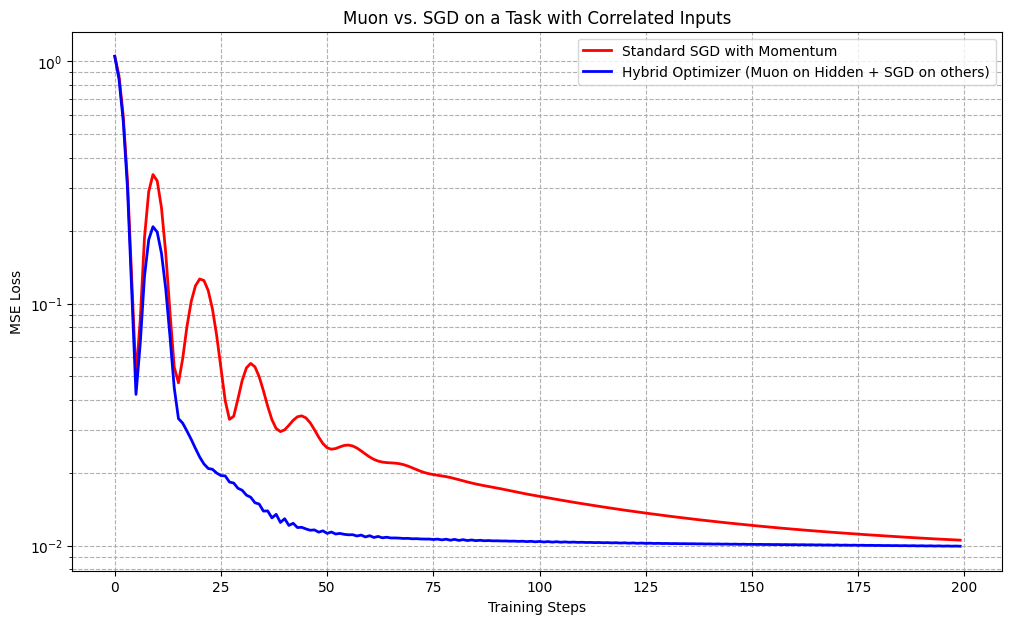

In [23]:

loss_sgd = train('sgd')
loss_muon = train('muon_hybrid')

plt.figure(figsize=(12, 7))
plt.plot(loss_sgd, label='Standard SGD with Momentum', color='red', linewidth=2)
plt.plot(loss_muon, label='Hybrid Optimizer (Muon on Hidden + SGD on others)', color='blue', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.title('Muon vs. SGD on a Task with Correlated Inputs')
plt.legend()
plt.grid(True, which="both", ls="--")
# plt.show()